# Decoded Plots

In [29]:
import sys
import importlib
import pandas as pd
from pathlib import Path

repo_src = None
repo_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "plots" / "plot_helpers.py").exists():
        repo_src = base / "src" / "plots"
        repo_root = base
        break
    if (base / "plots" / "plot_helpers.py").exists():
        repo_src = base / "plots"
        repo_root = base.parent
        break
    if (base / "plot_helpers.py").exists():
        repo_src = base
        repo_root = base.parent.parent
        break

if repo_src is None or repo_root is None:
    raise FileNotFoundError("Could not locate plot_helpers.py")

if str(repo_src) not in sys.path:
    sys.path.insert(0, str(repo_src))

import plot_helpers

importlib.reload(plot_helpers)

paths = {
    "decoded": repo_root / "output" / "decoded.csv",
    "decoded_bpsk": repo_root / "output" / "decoded_bpsk.csv",
    "decoded_ecc_bpsk": repo_root / "output" / "decoded_ecc_bpsk.csv",
    "decoded_ecc_dbpsk": repo_root / "output" / "decoded_ecc_dbpsk.csv",
    "decoded_no_wa_dbpsk": repo_root / "output" / "encode_decode_no_wa_dbpsk.csv",
    "decoded_no_wa_bpsk": repo_root / "output" / "encode_decode_no_wa_bpsk.csv",
    "decoded_no_wa_dbpsk_4": repo_root / "output" / "encode_decode_no_wa_dbpsk_4.csv",
    "decoded_no_wa_bpsk_4": repo_root / "output" / "encode_decode_no_wa_bpsk_4.csv",
    "decoded_no_wa_dbpsk_8": repo_root / "output" / "encode_decode_no_wa_dbpsk_8.csv",
    "decoded_no_wa_bpsk_8": repo_root / "output" / "encode_decode_no_wa_bpsk_8.csv",
    "decoded_no_wa_bpsk_16": repo_root / "output" / "encode_decode_no_wa_bpsk_16.csv",
    "prova_nuova": repo_root / "output" / "prova_nuova.csv",
    "decoded_no_wa_backup": repo_root / "output" / "encode_decode_no_wa.csv.bak",
    "without_end_preamble": repo_root
    / "output"
    / "encode_decode_no_wa_no_end_preamble.csv",
}

df_first = pd.read_csv(
    paths["decoded_no_wa_bpsk_8"],
)
df_second = pd.read_csv(
    paths["prova_nuova"],
)

LABEL_FIRST: str = "dbpsk no ecc"
LABEL_SECOND: str = "dbpsk with ecc"

# Comparison between DBPSK and BPSK
From this comparison we can analyze what actually gets recognized in the file: is the preamble recognized? Is the decoded payload long enough?
These are the possible errors:
* `not-valid-preamble`: the preamble has not been recognized
* `check-error`: safety guards on the waveform properties
* `no-length-in-header`: the header is shorter than 16 bits, which are used to represent the number of bytes of the payload
* `paylod-too-short`: the payload is shorter than the number of bytes that are in the header

If there is no error, the status is `valid-preamble`.

In [30]:
from plot_helpers import print_decode_status, print_error_comparison

print(f"{LABEL_FIRST}:")
print_decode_status(df_first)
print()
print(f"{LABEL_SECOND}:")
print_decode_status(df_second)
print()
print_error_comparison(
    df_first,
    df_second,
    LABEL_FIRST,
    LABEL_SECOND,
)

dbpsk no ecc:
valid preambles: 491
not valid: 0
errors: 9
types of error: ['unsupported-header-version']

dbpsk with ecc:
valid preambles: 251
not valid: 181
errors: 68
types of error: ['paylod-too-short', 'unsupported-header-version', 'unsupported-ecc-scheme']

Mean error dbpsk no ecc: 0.0195
Mean error dbpsk with ecc: 0.834
Variance error dbpsk no ecc: 0.0177
Variance error dbpsk with ecc: 0.1021

dbpsk no ecc is better than dbpsk with ecc: 453, 90.6%
dbpsk no ecc is equal to dbpsk with ecc: 43, 8.6%
dbpsk no ecc is worse than dbpsk with ecc: 4, 0.8%
Mean improvement: -0.8998
Improvement variance: 0.0493
Mean worsening: 0.0917
Worsening variance: 0.0116


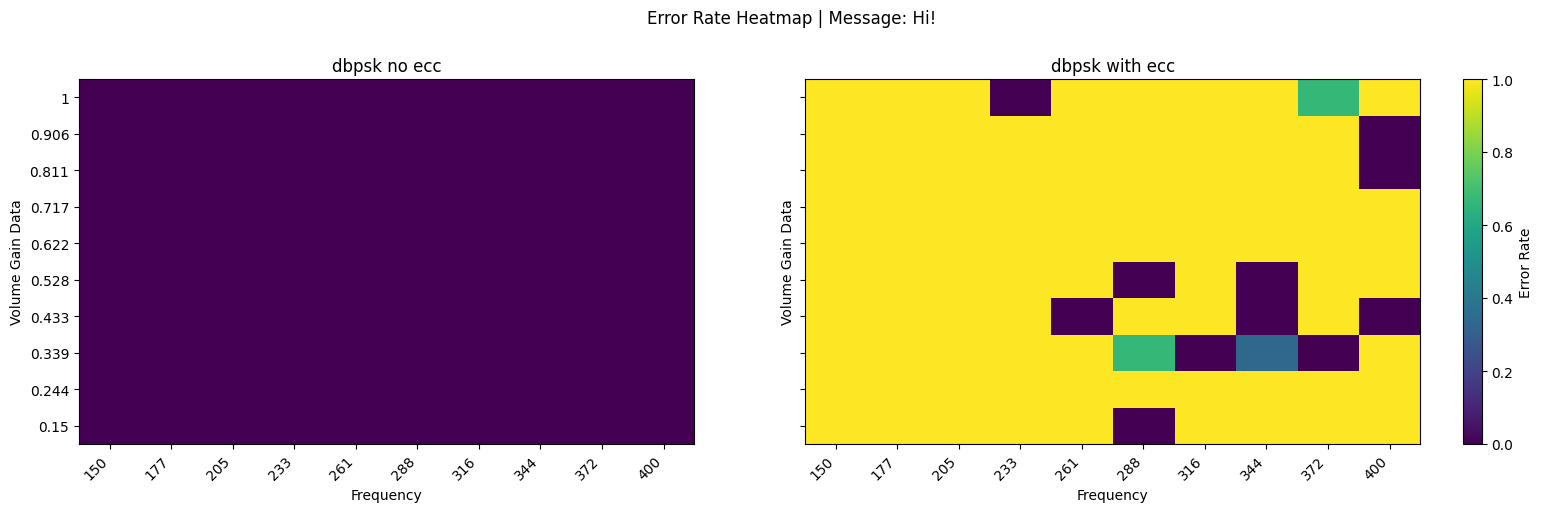

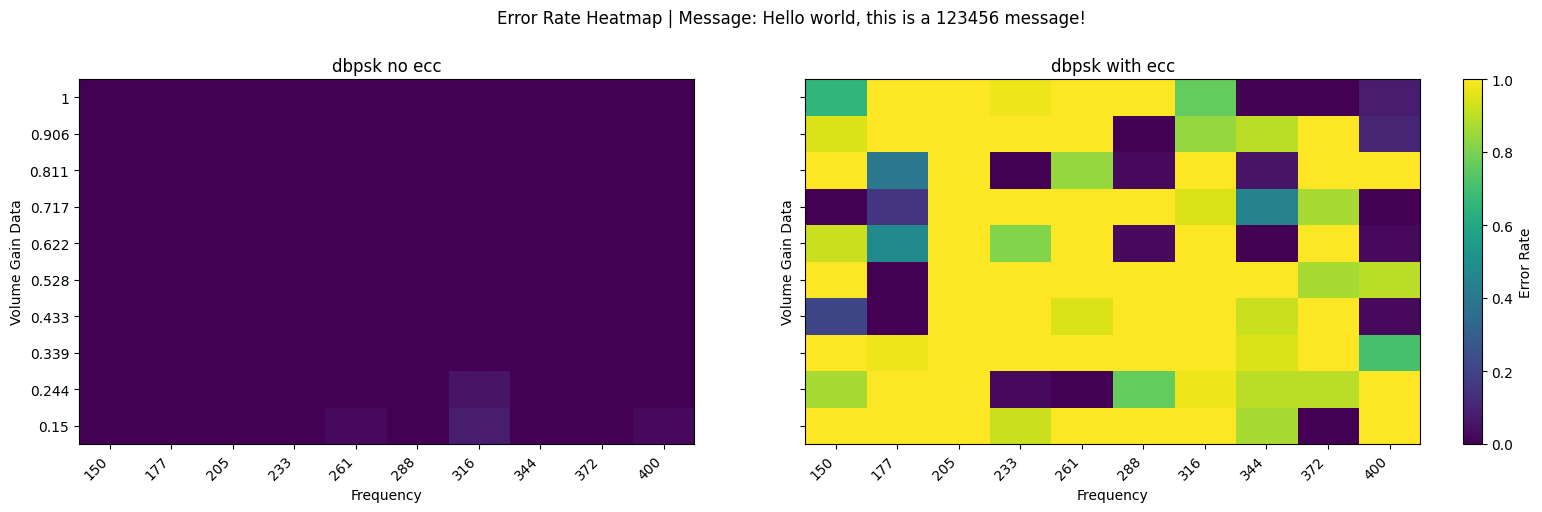

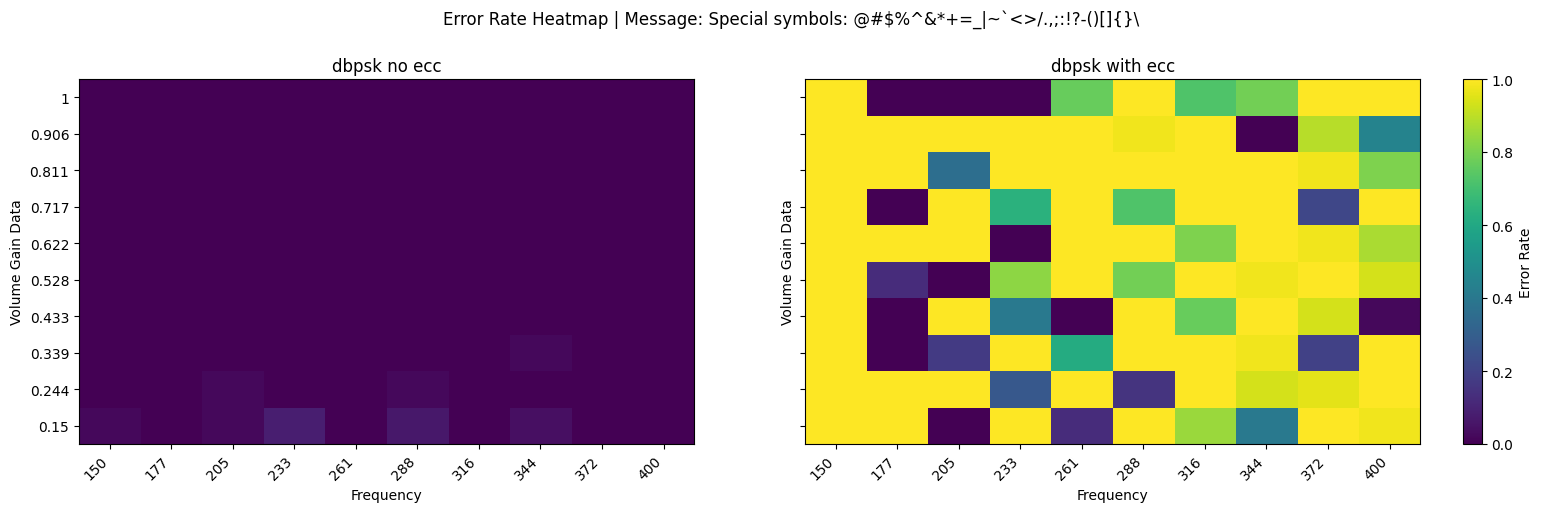

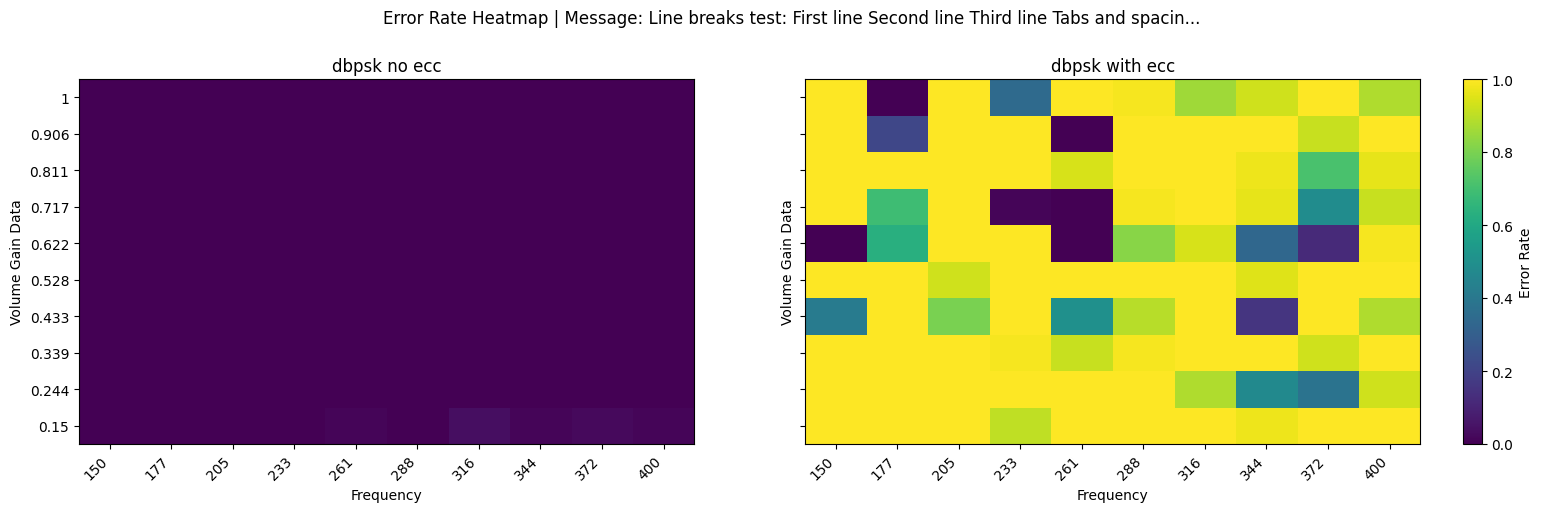

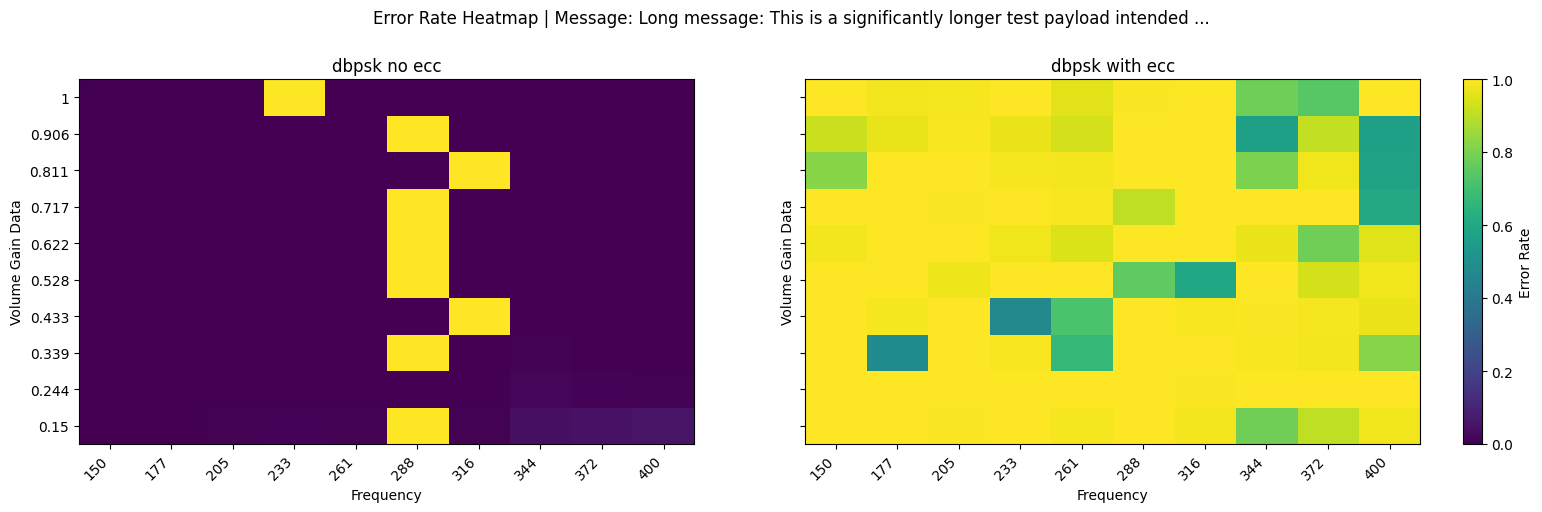

In [31]:
from plot_helpers import plot_error_rate_heatmaps_by_message_comparison

plot_error_rate_heatmaps_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate vs Frequency (Comparison per Message)
Each figure is split into two columns for direct comparison between actual and best-case runs.

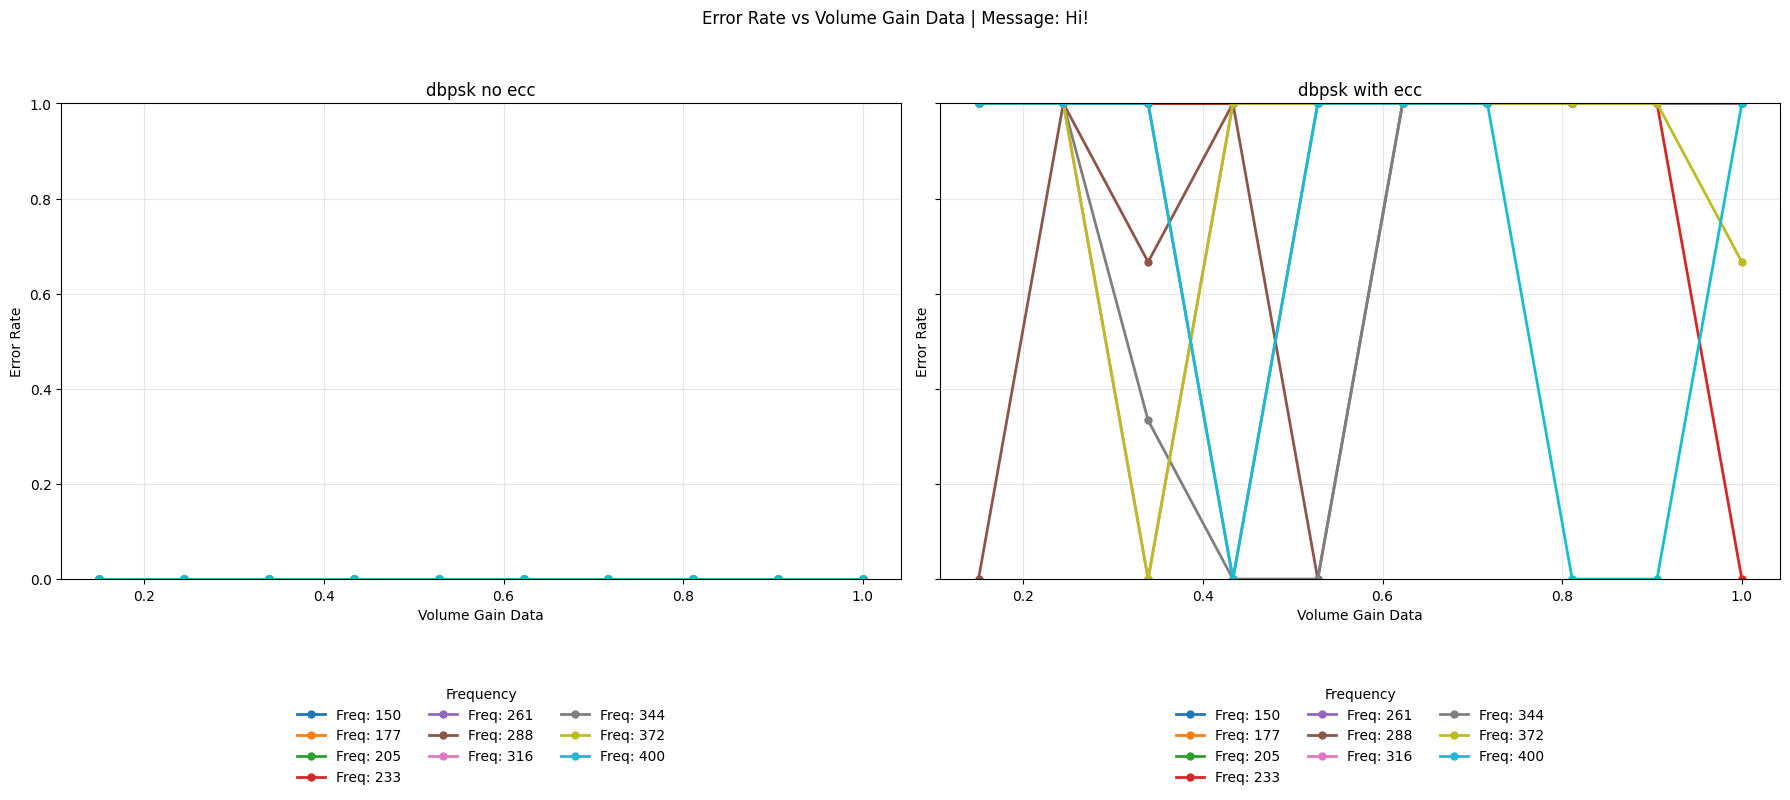

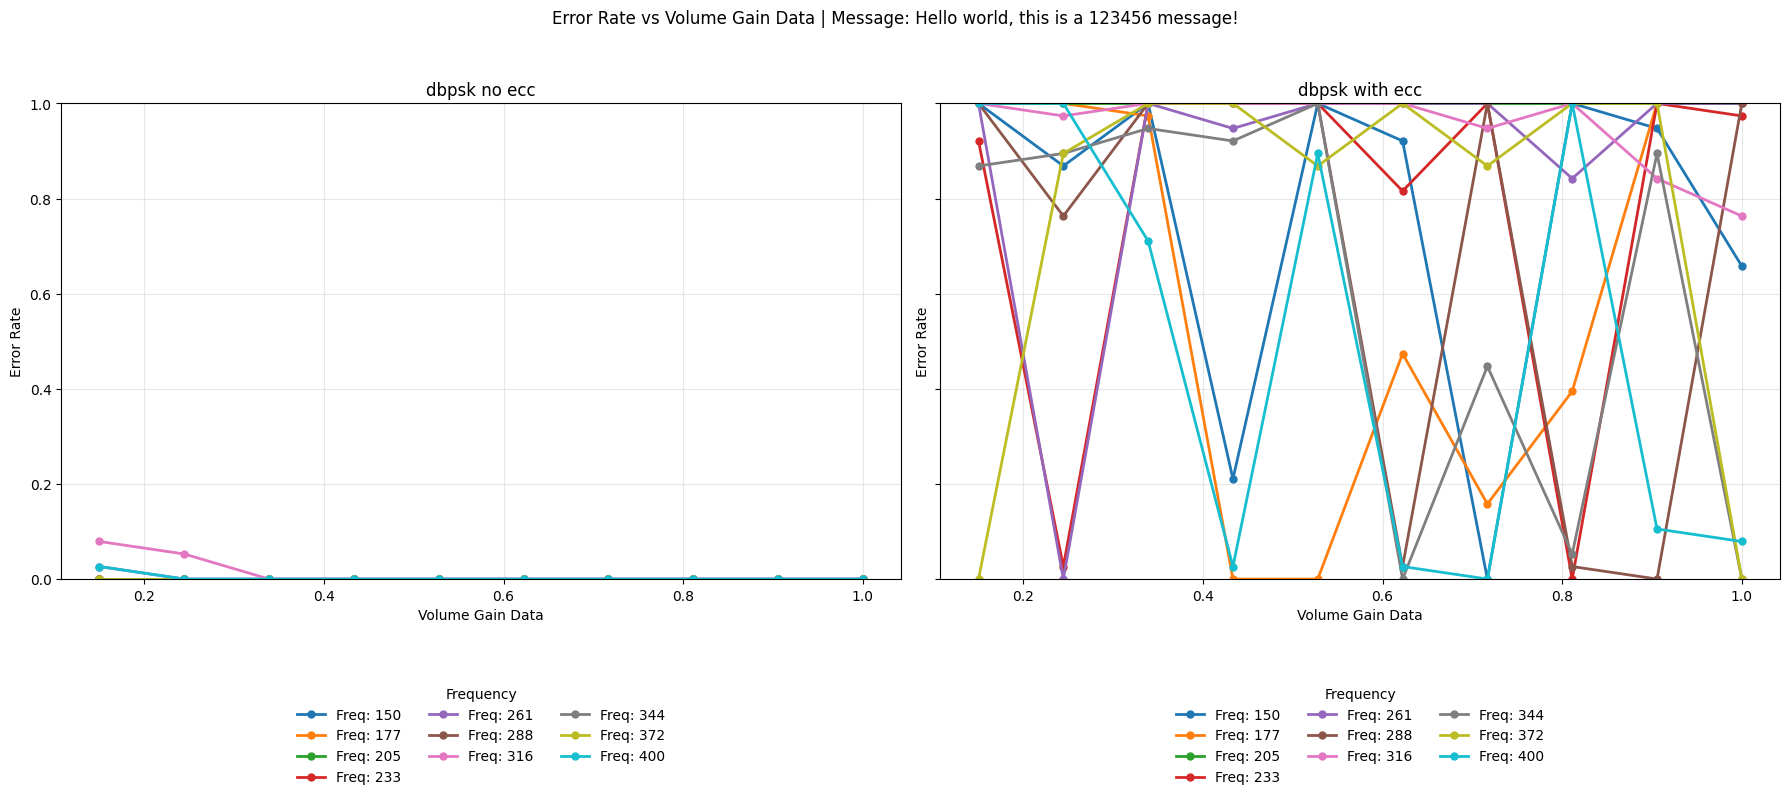

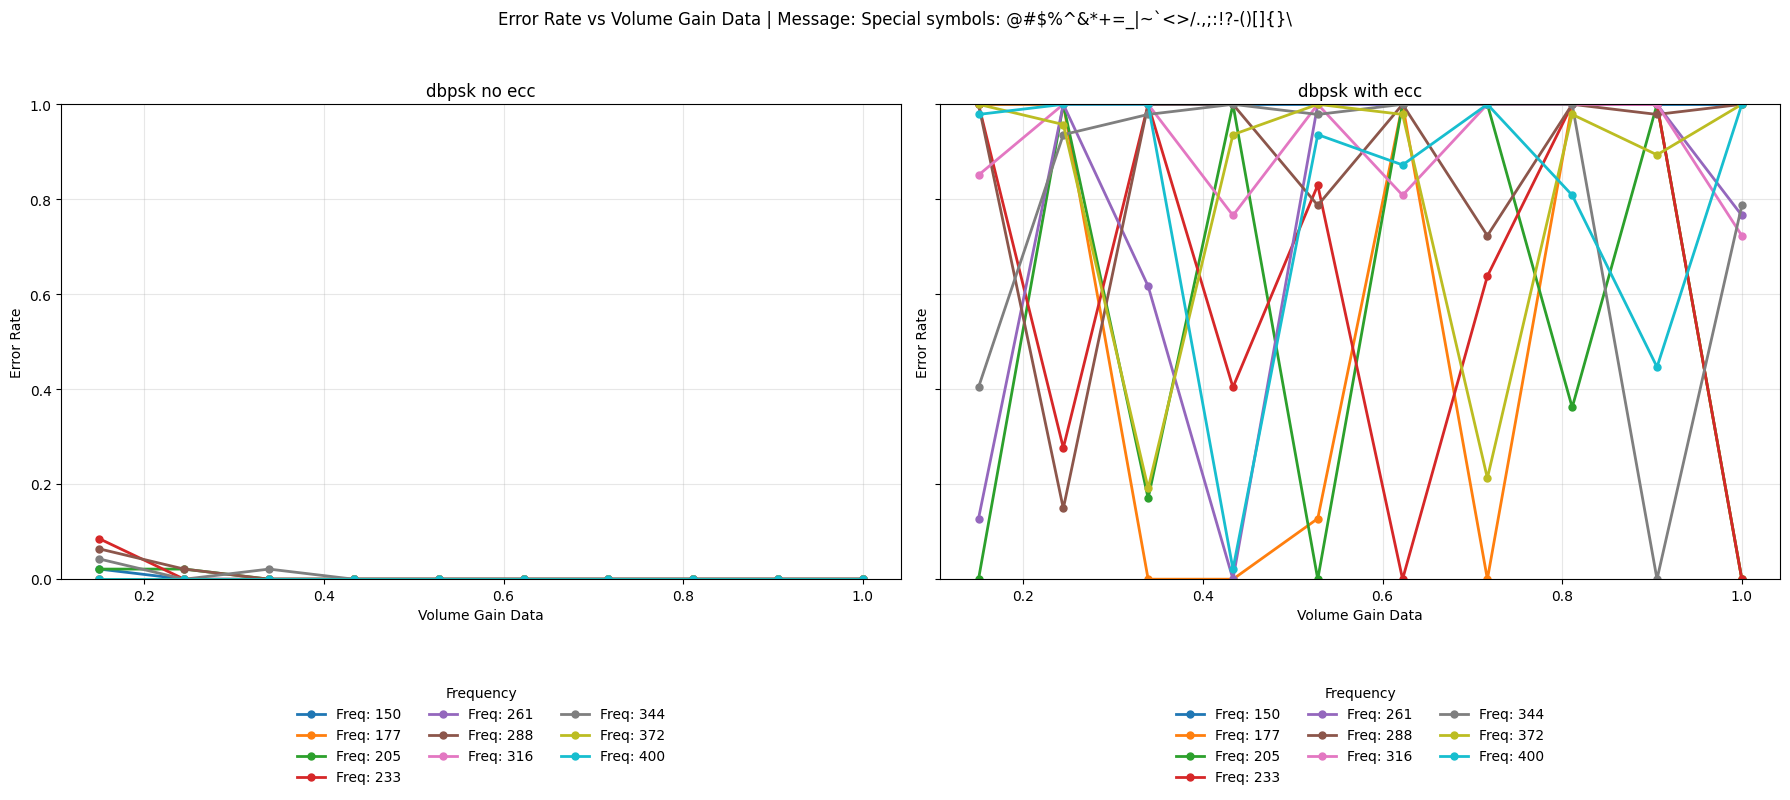

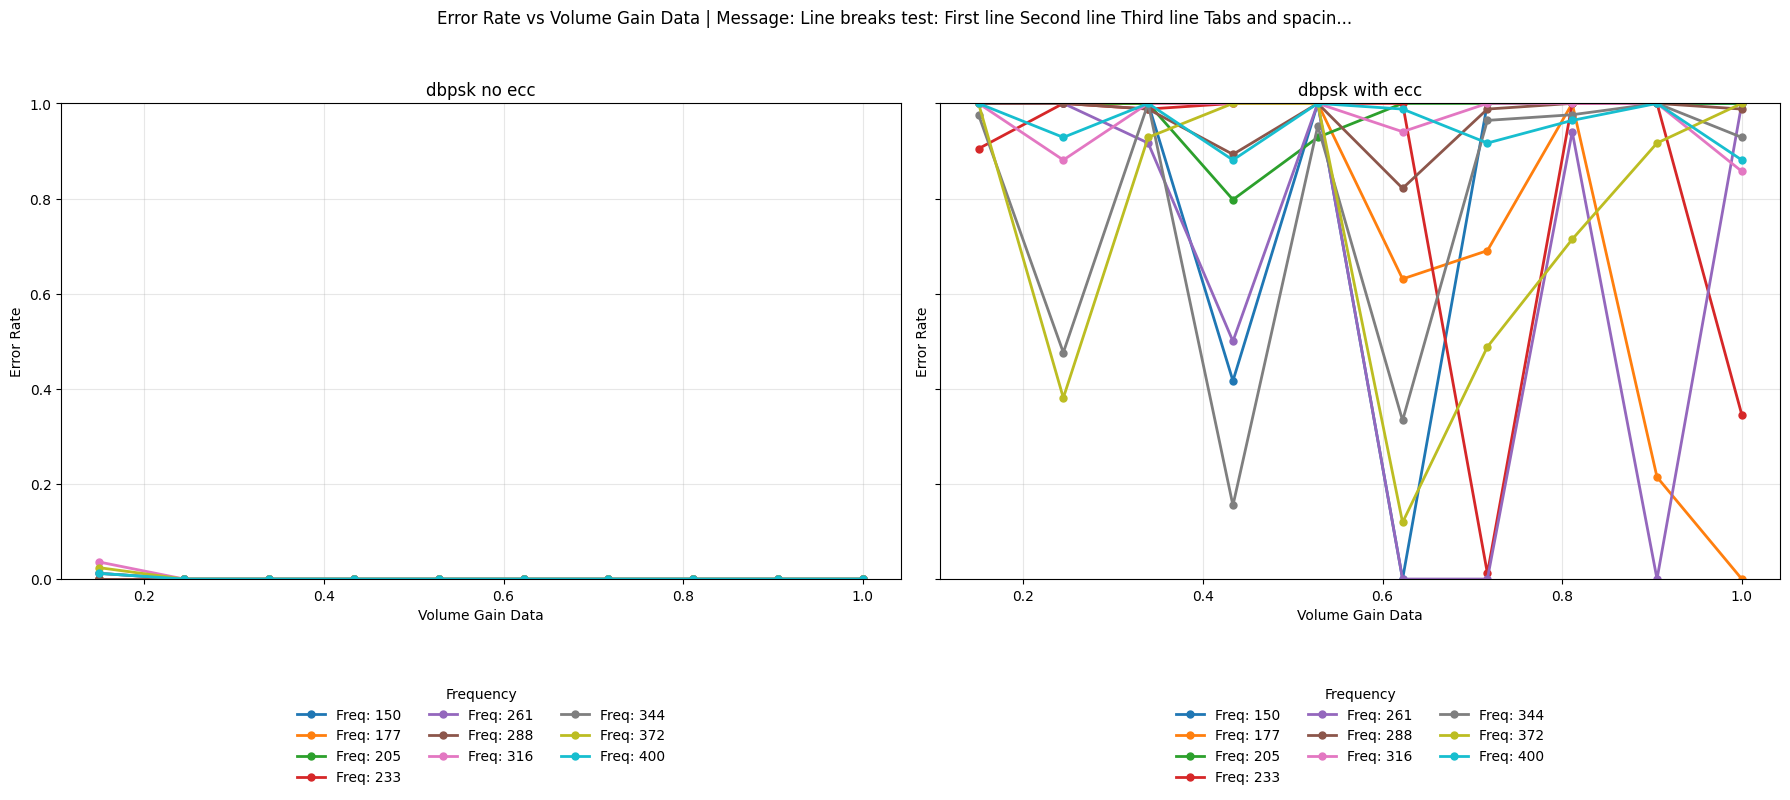

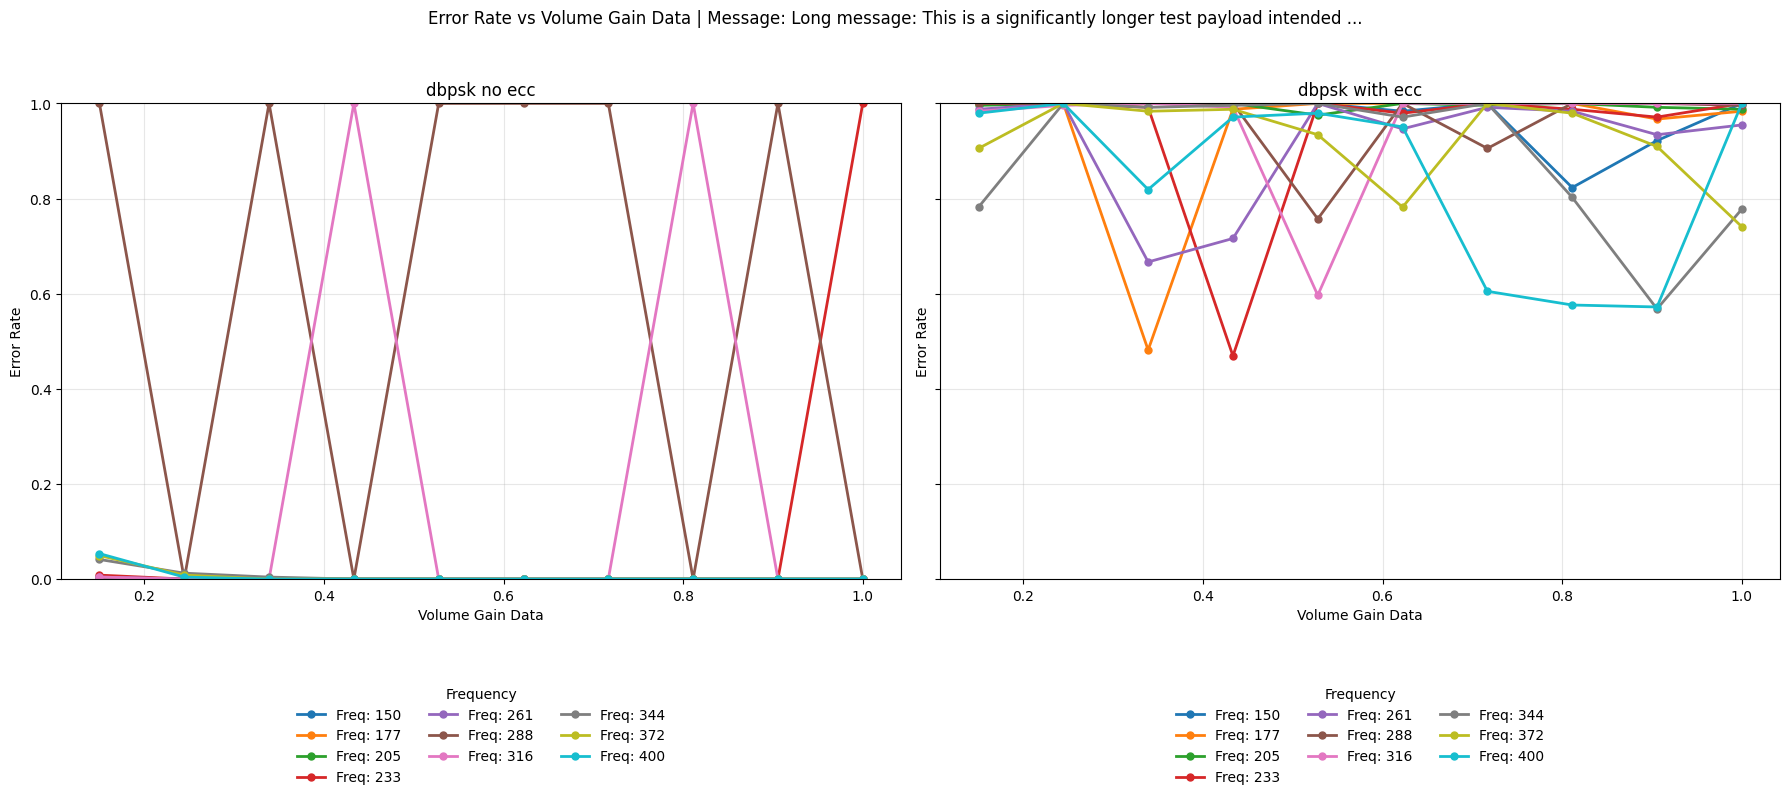

In [32]:
from plot_helpers import plot_error_rate_vs_frequency_by_message_comparison

plot_error_rate_vs_frequency_by_message_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## Error Rate Variance by Frequency (All Volume Gain Data Values, Comparison)
This section generates one comparison figure per available `volume_gain_data` value.
Each figure has:
- Column A: `csv_path`
- Column B: `no_audio_compression`
Violin plots are used by default and automatically fall back to box plots when groups are sparse.

Generating 10 comparison plots (one per volume_gain_data).


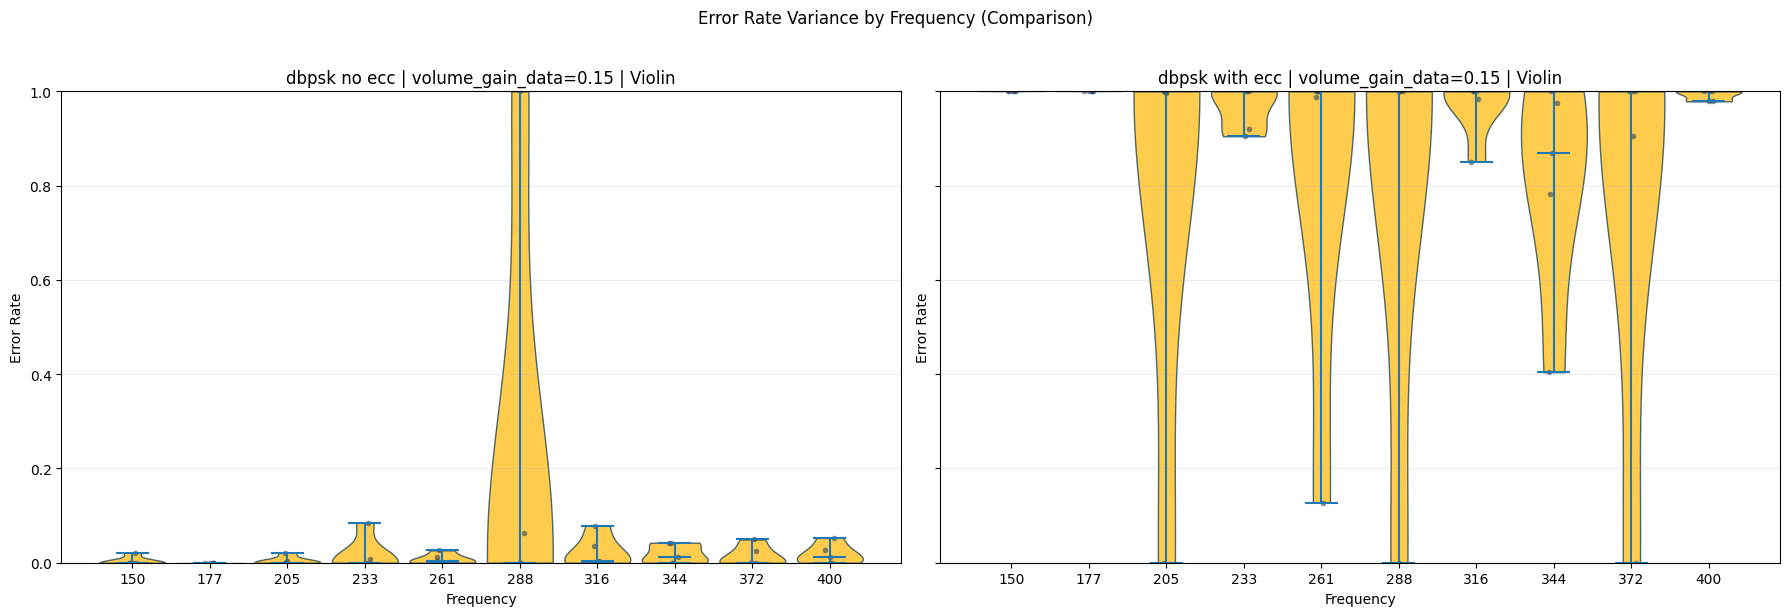

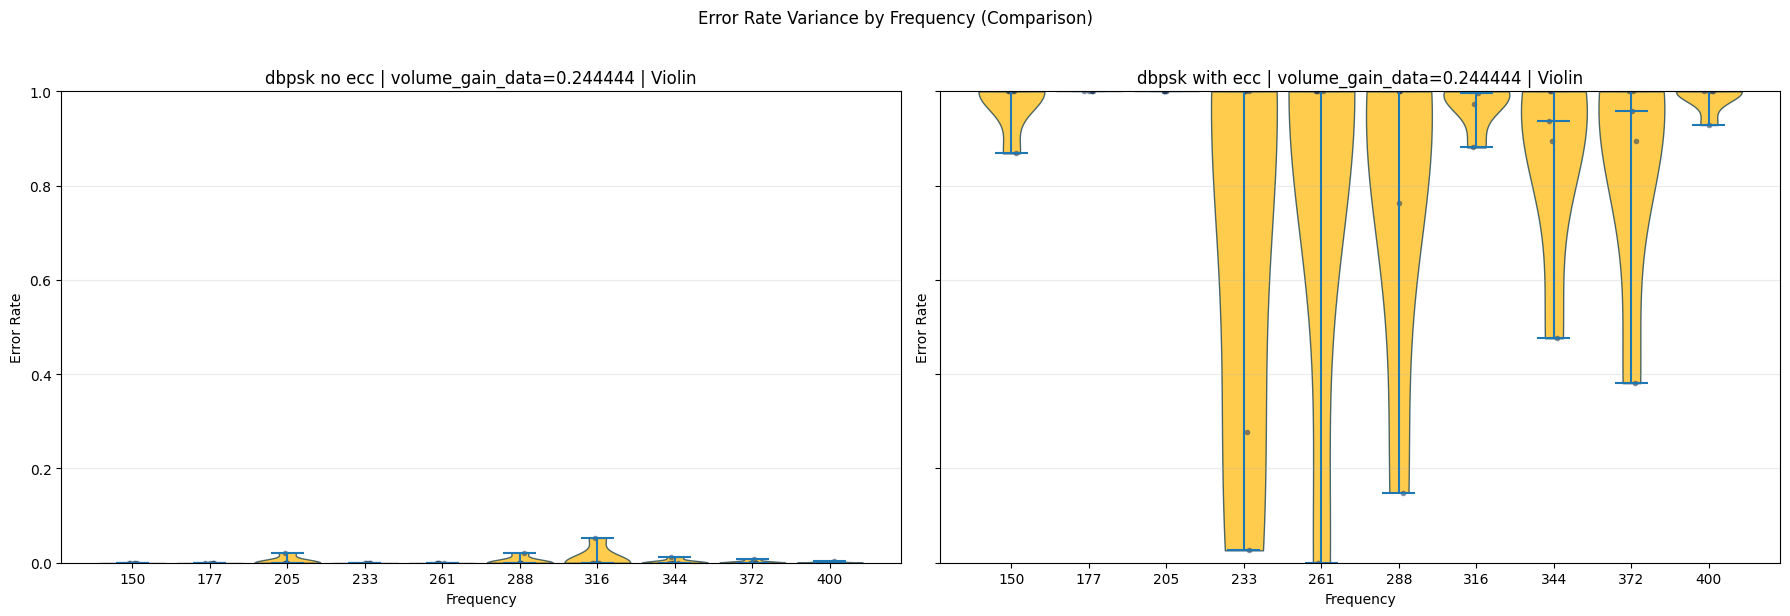

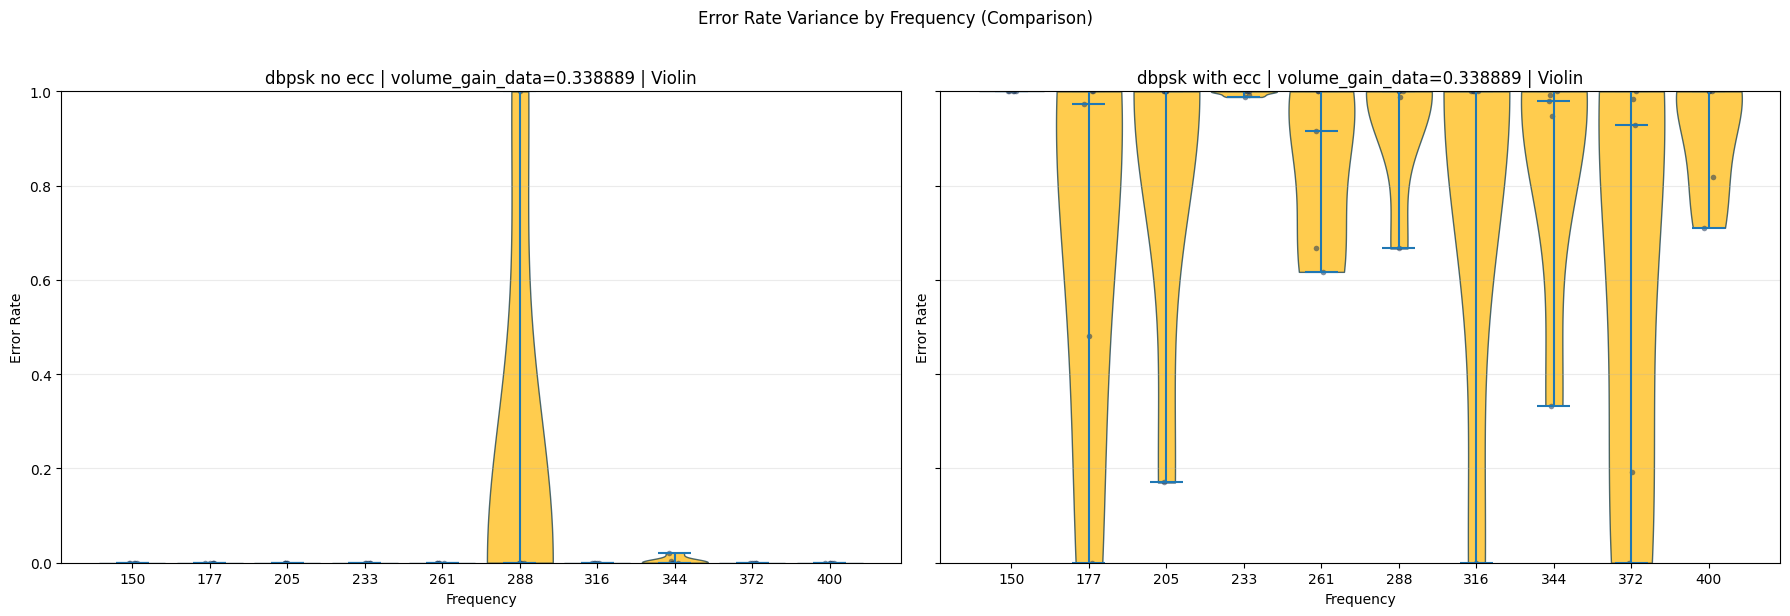

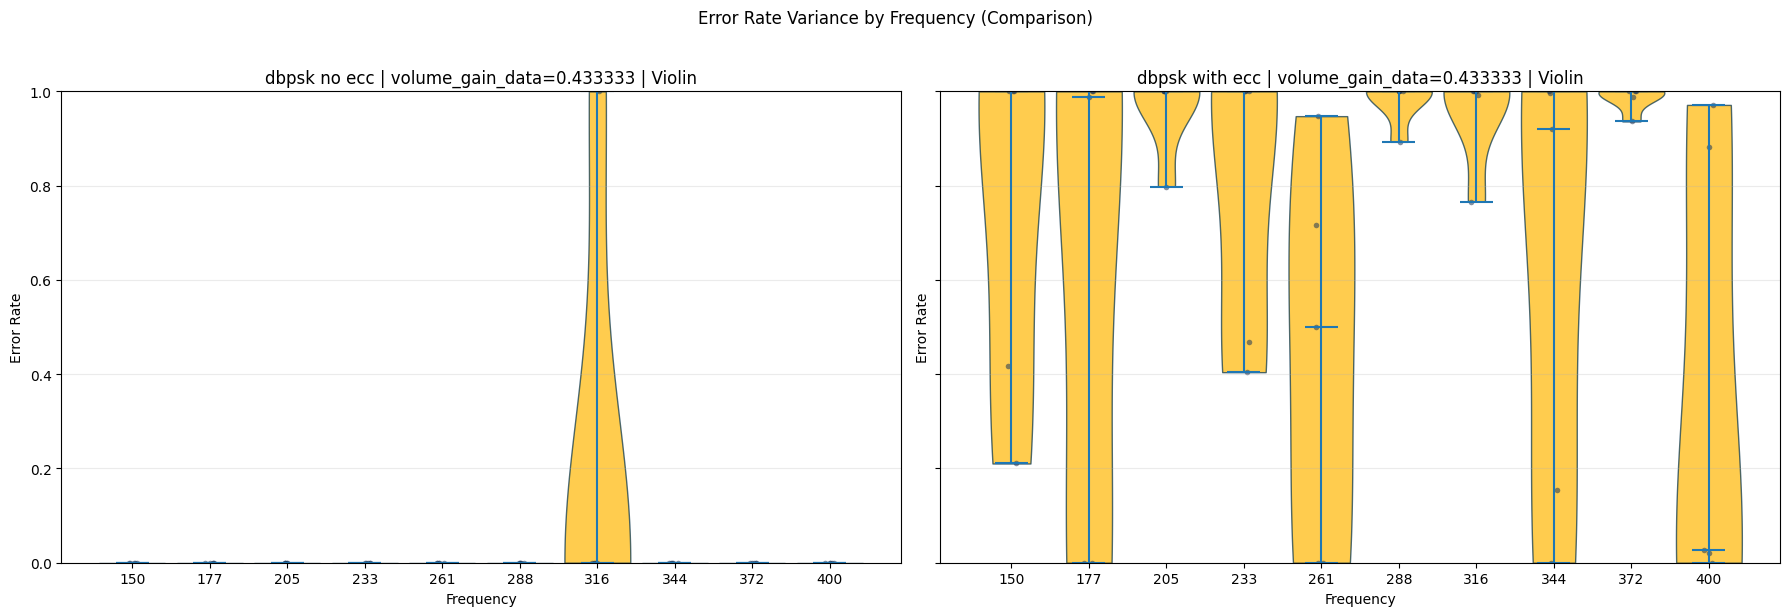

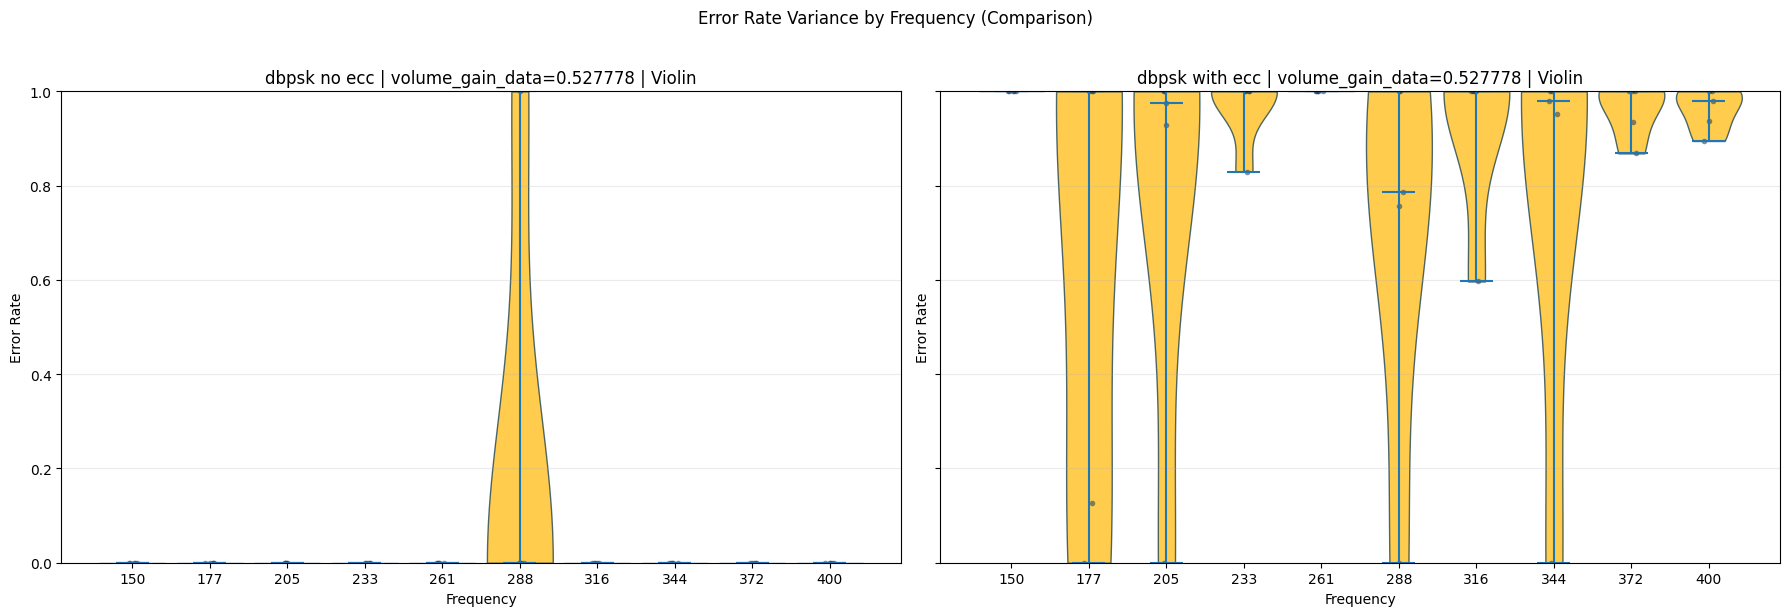

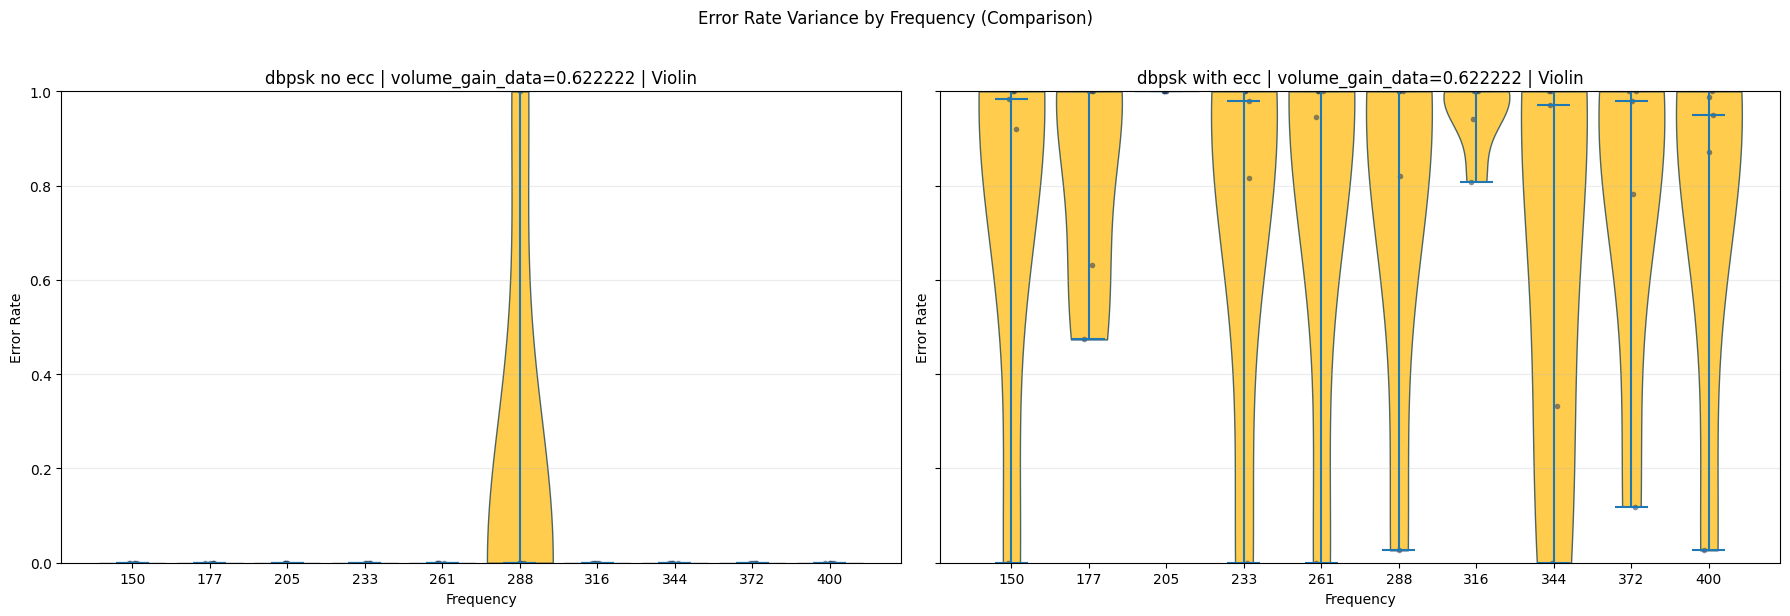

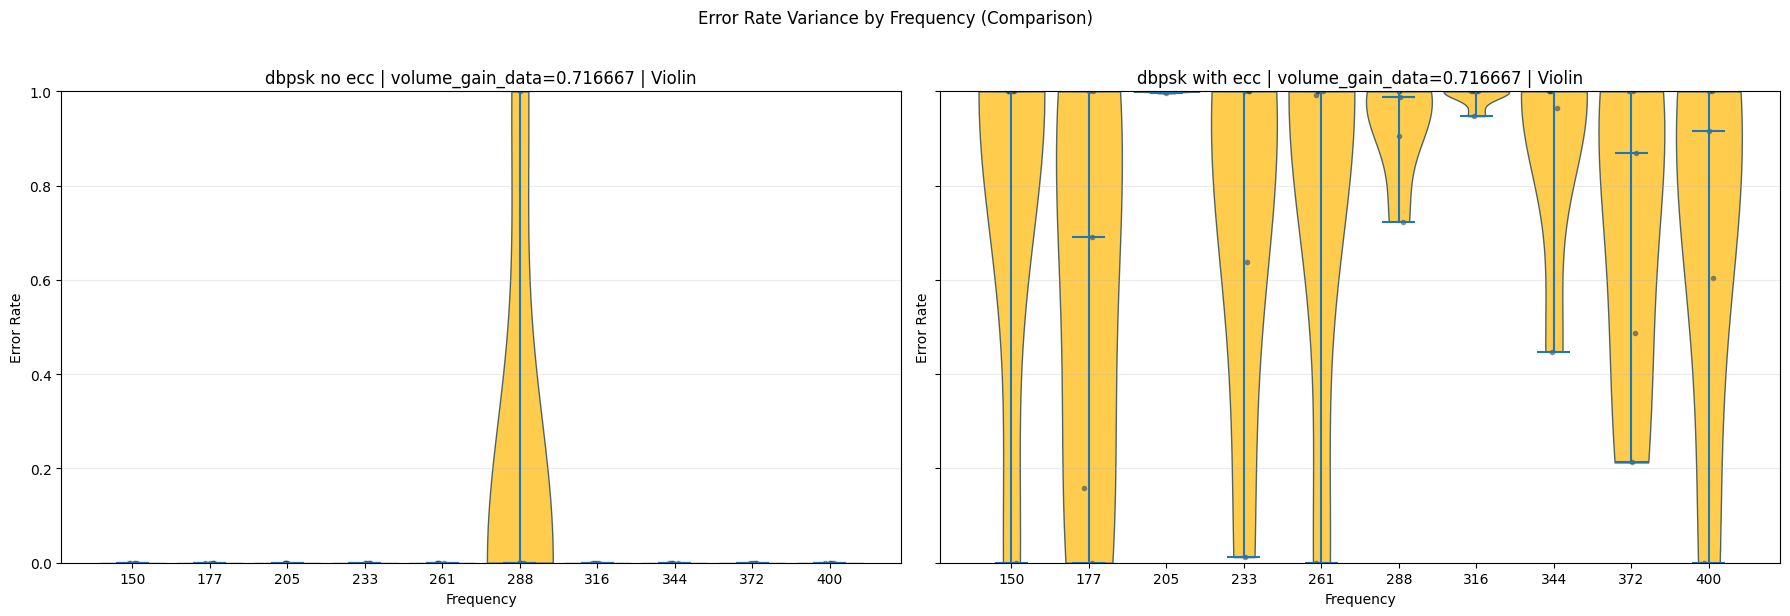

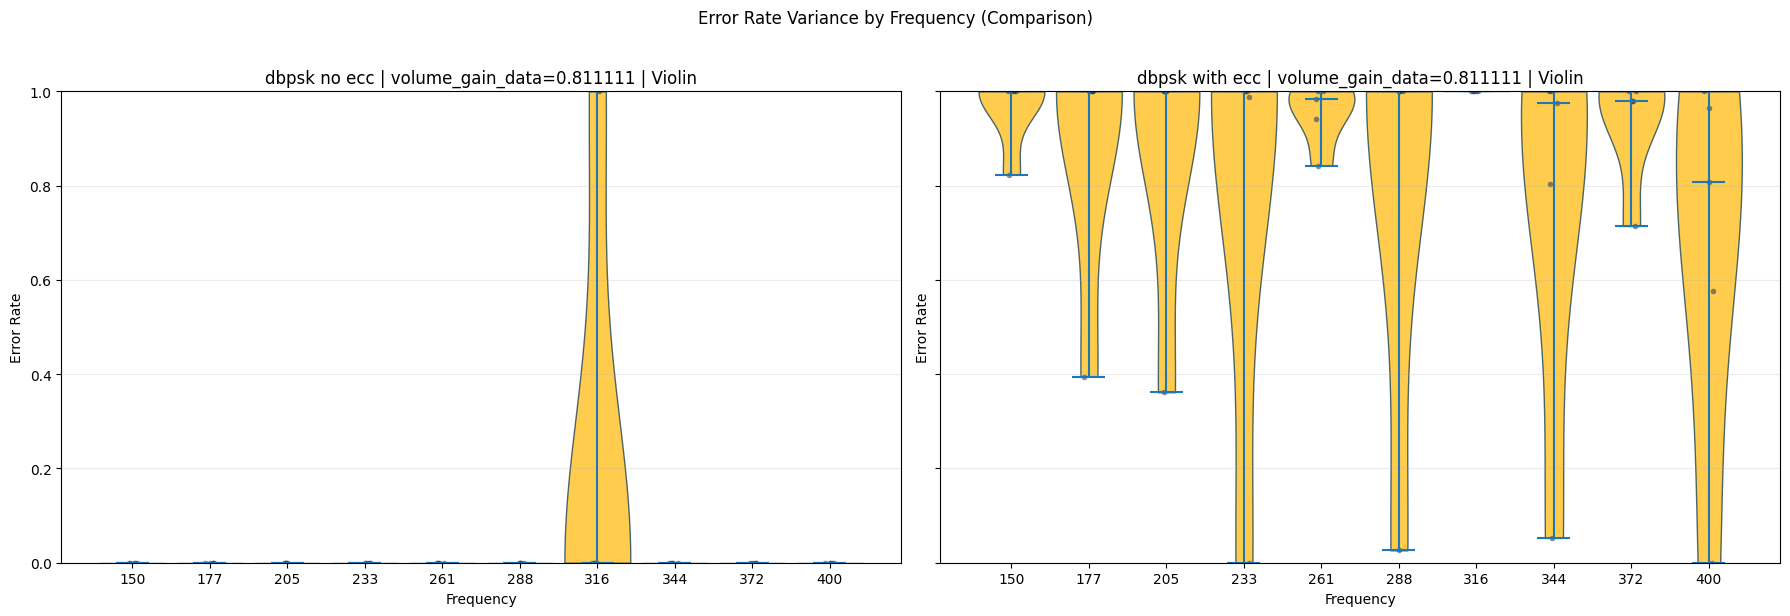

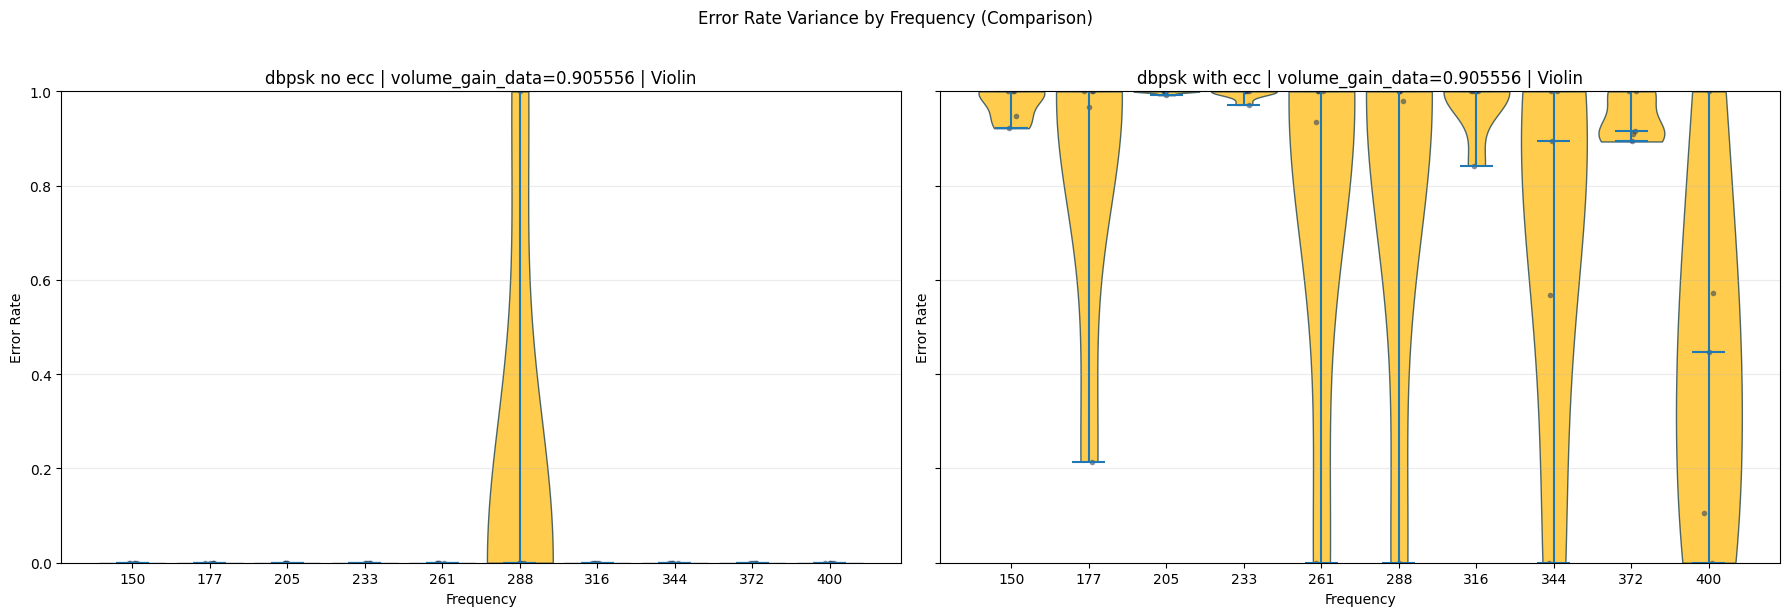

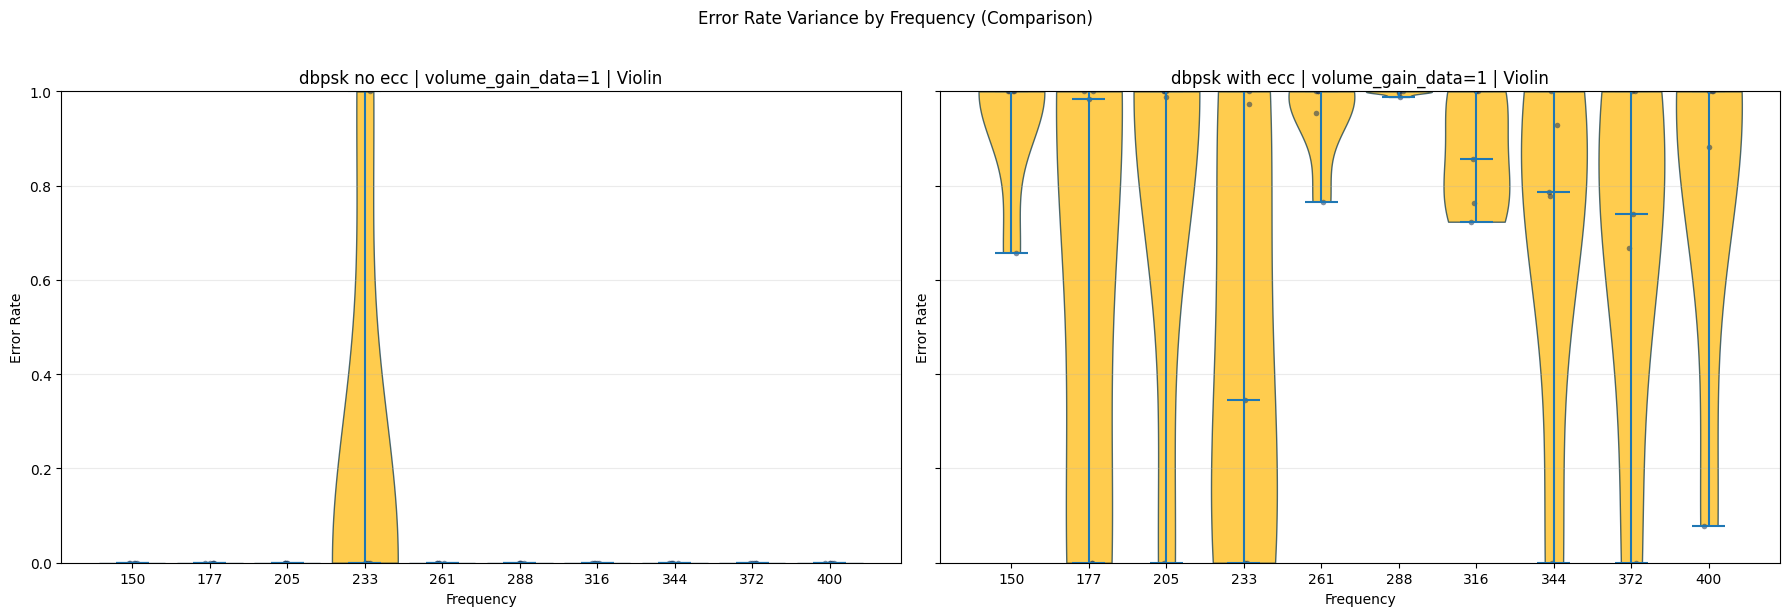

In [33]:
from plot_helpers import plot_error_rate_variance_for_all_volume_gains_comparison

plot_error_rate_variance_for_all_volume_gains_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
    prefer_box_if_sparse=True,
    min_points_per_group=5,
)

## 3D Static Render (Non-interactive)
This adds a static 3D view of the same comparison data without changing the interactive Plotly figure above.

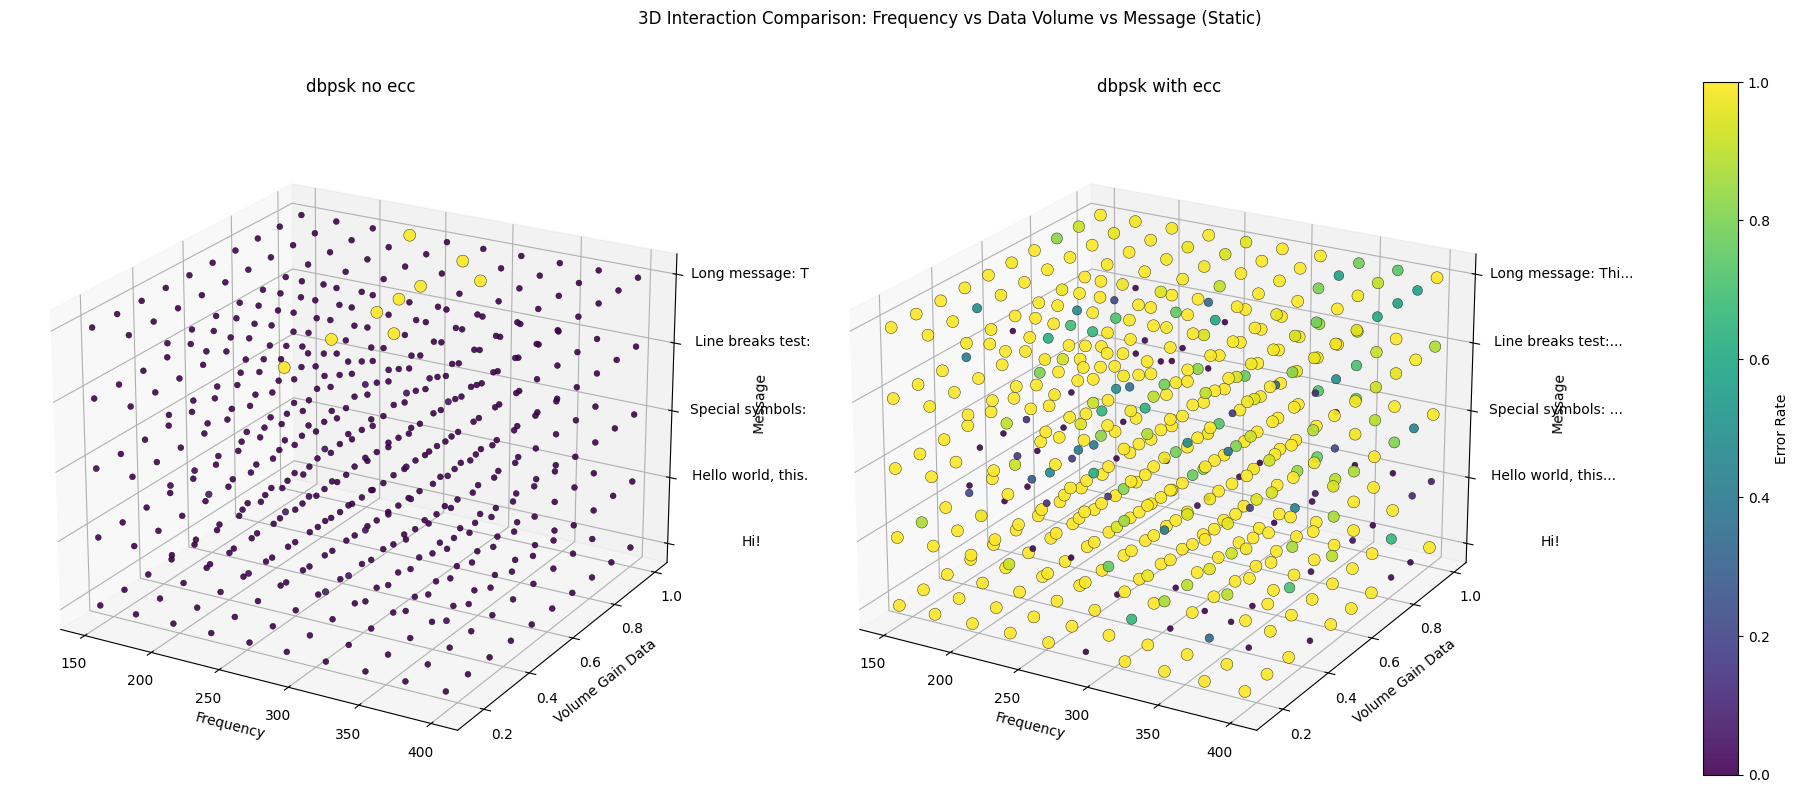

In [34]:
from plot_helpers import plot_static_3d_interaction_comparison

plot_static_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)

## 3D Interaction: Frequency, Data Volume, and Message (Comparison)
This figure is split into two 3D panels:
- Column A: `csv_path` (actual pipeline output)
- Column B: `no_audio_compression` (best-case reference)
Color and marker size encode `error_rate` (lower is better).

In [35]:
from plot_helpers import plot_3d_interaction_comparison

plot_3d_interaction_comparison(
    df_first,
    df_second,
    label_a=LABEL_FIRST,
    label_b=LABEL_SECOND,
)